In [21]:
# Liesel
import liesel.model as lsl
import liesel.goose as gs

# Tensorflow
from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

# Jax
import jax.numpy as jnp
import jax

# Plotting
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# Utils
import numpy as np
import pandas as pd
import datetime
import time
import json
import pickle
import os

## Margarine Data

In [22]:
# ============
# DATA LOADING 
# ============
def load_margarine_data(filepath):
    """Loads and preprocesses the margarine dataset."""
    with open(filepath, 'r') as f:
        raw_data = json.load(f)
    
    X_list, y_list, Z_list, unit_indices = [], [], [], []
    
    n_alts_orig = 10
    kept_alts_1based = np.array([1, 2, 3, 4, 5, 7])
    kept_alts_0based = kept_alts_1based - 1 
    p = len(kept_alts_0based) 
    y_mapping = {val: idx for idx, val in enumerate(kept_alts_1based)}
    unit_idx_counter = 0
    
    for respondent in raw_data:
        X_raw = np.array(respondent['X'])
        y_raw = np.array(respondent['y'])
        
        if y_raw.ndim == 0:
            y_raw = np.atleast_1d(y_raw)
        
        n_choice_occasions_orig = len(y_raw)
        n_params_orig = X_raw.shape[1]
        X_reshaped = X_raw.reshape((n_choice_occasions_orig, n_alts_orig, n_params_orig))
        
        valid_occasions = np.isin(y_raw, kept_alts_1based)
        y_filtered = y_raw[valid_occasions]
        X_filtered = X_reshaped[valid_occasions]
        
        n_obs = len(y_filtered)
        if n_obs < 5:
            continue
            
        Z_raw = np.array(respondent.get('Z_raw', [1.0, 1.0]))
        Z_list.append(Z_raw)
        y_recoded = np.array([y_mapping[val] for val in y_filtered])
        X_new = np.zeros((n_obs, p, p))
        
        for r in range(n_obs):
            orig_prices = X_filtered[r, kept_alts_0based, 9]
            log_prices = np.log(orig_prices)
            X_new[r, 1:, 0:5] = np.eye(5)
            X_new[r, :, 5] = log_prices
            
        X_list.append(X_new)
        y_list.append(y_recoded)
        unit_indices.extend([unit_idx_counter] * n_obs)
        unit_idx_counter += 1

        # Updated de-meaning for 
        Z_arr = np.array(Z_list)
        Z_arr[:, 0] = np.log(Z_arr[:, 0]) # Log Income

        # ADDED LINES TO CENTER THE DATA
        Z_arr[:, 0] -= np.mean(Z_arr[:, 0]) # De-mean Log Income
        Z_arr[:, 1] -= np.mean(Z_arr[:, 1]) # De-mean Family Size

        # Proceed with adding the intercept
        Z_intercept = np.ones((Z_arr.shape[0], 1))
        Z_final = np.concatenate([Z_intercept, Z_arr], axis=1)

    return {
        "X": jnp.array(np.concatenate(X_list, axis=0)),
        "y": jnp.array(np.concatenate(y_list, axis=0)),
        "Z": jnp.array(Z_final),
        "unit_idx": jnp.array(unit_indices),
        "n_units": unit_idx_counter,
        "n_params": p,
        "n_z": Z_final.shape[1]
    }

In [23]:
print("Loading data...")
data_dict = load_margarine_data("margarine_data.json")

# Extract k_dim to the global notebook scope
k_dim = int(data_dict["n_params"])

print(f"Data Loaded: {data_dict['n_units']} units, {k_dim} parameters, {data_dict['n_z']} demographic vars")
print(f"Total Observations: {data_dict['y'].shape[0]}")

Loading data...
Data Loaded: 313 units, 6 parameters, 3 demographic vars
Total Observations: 3405


## Hierarchical Bayesian Multinomial Logit Model

In [24]:
# FACTORY FUNCTIONS
def make_wishart(df, scale_tril):
    return tfd.WishartTriL(
        df=df, 
        scale_tril=scale_tril, 
        input_output_cholesky=True, 
        validate_args=False
    )

def make_mvn_precision(loc, precision_factor):
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor),
        validate_args=False
    )

In [25]:
# ==============
# MODEL BUILDING
# ==============
def build_hmnl_model(data_dict, A_val=0.01):
    """Constructs the Hierarchical MNL model using Liesel."""
    k_dim = int(data_dict["n_params"]) 
    n_units = int(data_dict["n_units"])
    n_z = int(data_dict["n_z"])

    nu_val = float(k_dim + 3)
    V_inv_val = jnp.linalg.inv(nu_val * jnp.eye(k_dim))
    Vinv_chol_val = jnp.linalg.cholesky(V_inv_val)

    sigma_inv_chol = lsl.Var.new_param(
        value=jnp.eye(k_dim),
        distribution=lsl.Dist(make_wishart, df=nu_val, scale_tril=Vinv_chol_val),
        name="sigma_inv_chol"
    )

    sigma_inv_chol_latent = sigma_inv_chol.transform(
        tfb.FillScaleTriL(), 
        name="sigma_inv_chol_latent"
    )

    delta_prec_factor = lsl.Var.new_calc(
        lambda L: jnp.sqrt(A_val) * L, 
        L=sigma_inv_chol, 
        name="delta_prec_factor"
    )

    Delta = lsl.Var.new_param(
        value=jnp.zeros((n_z, k_dim)),
        distribution=lsl.Dist(
            make_mvn_precision, loc=jnp.zeros(k_dim), precision_factor=delta_prec_factor
        ),
        name="Delta"
    )

    Z_var = lsl.Var.new_obs(data_dict["Z"], name="Z_obs")
    beta_mean = lsl.Var.new_calc(lambda Z, D: jnp.dot(Z, D), Z=Z_var, D=Delta, name="beta_mean")

    beta_i = lsl.Var.new_param(
        value=jnp.zeros((n_units, k_dim)),
        distribution=lsl.Dist(make_mvn_precision, loc=beta_mean, precision_factor=sigma_inv_chol),
        name="beta_i"
    )

    X_var = lsl.Var.new_obs(data_dict["X"], name="X_obs")
    idx_var = lsl.Var.new_obs(data_dict["unit_idx"], name="idx_obs")

    beta_expanded = lsl.Var.new_calc(lambda b, idx: b[idx], b=beta_i, idx=idx_var, name="beta_expanded")
    logits = lsl.Var.new_calc(lambda x, b: jnp.einsum("nij,nj->ni", x, b), x=X_var, b=beta_expanded, name="logits")

    y_var = lsl.Var.new_obs(data_dict["y"], distribution=lsl.Dist(tfd.Categorical, logits=logits), name="y")

    return lsl.Model([y_var])


def run_inference(model, chains=1, warmup=1000, posterior=10000, seed=123):
    """Sets up the MCMC engine and samples from the model."""
    eb = gs.EngineBuilder(seed=seed, num_chains=chains)
    eb.set_model(gs.LieselInterface(model))
    eb.set_initial_values(model.state)

    eb.add_kernel(gs.NUTSKernel(["sigma_inv_chol_latent"], mm_diag=False))
    eb.add_kernel(gs.NUTSKernel(["Delta"])) 
    eb.add_kernel(gs.NUTSKernel(["beta_i"]))

    eb.set_duration(warmup_duration=warmup, posterior_duration=posterior)

    print("Starting Sampling...")
    engine = eb.build()
    engine.sample_all_epochs()

    return engine.get_results().get_posterior_samples()

In [26]:
# Start measuring runtime
start_time = time.time()

# Build model using data
print("Building model...")
model = build_hmnl_model(data_dict)

# This is where the heavy computation happens
n_warmup = 1000
n_posterior_samples = 10000
samples = run_inference(model, warmup=n_warmup, posterior=n_posterior_samples)

end_time = time.time()
formatted_time = str(datetime.timedelta(seconds=int(end_time - start_time)))
print(f"Sampling finished in {formatted_time} (H:M:S)")

# Save samples to the Data subfolder 
output_dir = "Data"
os.makedirs(output_dir, exist_ok=True) # Creates the folder if it doesn't exist

pkl_filename = os.path.join(output_dir, "liesel_posterior_samples_demeaned.pkl") 

print(f"Saving samples to {pkl_filename}...")
with open(pkl_filename, "wb") as f:
    pickle.dump(samples, f)
    
print("Samples saved successfully!")

Building model...


c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting Sampling...


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:18<00:00,  6.12s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 5 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 3 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 438.78chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 2 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 2 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 1 / 25 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - IN

Sampling finished in 0:05:28 (H:M:S)
Saving samples to Data\liesel_posterior_samples_demeaned.pkl...
Samples saved successfully!


In [ ]:
def generate_posterior_tables(samples, param_names, demo_names):
    """
    Calculates posterior means and standard deviations for Delta and the Covariance 
    matrix, returning formatted pandas DataFrames.
    
    Args:
        samples (dict): Dictionary of posterior samples.
        param_names (list): List of strings for the choice parameters (e.g., brands).
        demo_names (list): List of strings for the demographic variables.
        
    Returns:
        delta_df (pd.DataFrame): Formatted posterior of Delta.
        cov_corr_df (pd.DataFrame): Formatted stds and correlations of Betas.
    """
    k_dim = len(param_names)
    n_demos = len(demo_names)
    
    # Posterior distribution of Delta
    # Reshape dynamically using n_demos and k_dim
    delta_draws = samples["Delta"].reshape(-1, n_demos, k_dim)

    delta_mean = np.mean(delta_draws, axis=0)
    delta_std = np.std(delta_draws, axis=0)

    delta_df = pd.DataFrame(index=demo_names, columns=param_names)

    for i in range(n_demos):
        for j in range(k_dim):
            delta_df.iloc[i, j] = f"{delta_mean[i, j]: .2f} ({delta_std[i, j]:.2f})"

    # Covariance / Correlation of Betas
    latent_samples = samples["sigma_inv_chol_latent"].reshape(-1, int(k_dim * (k_dim + 1) / 2))
    bijector = tfb.FillScaleTriL()

    def latent_to_cov(latent_vec):
        L = bijector.forward(latent_vec)
        precision_mat = L @ L.T
        return jnp.linalg.inv(precision_mat)

    v_latent_to_cov = jax.vmap(latent_to_cov)
    cov_draws = np.array(v_latent_to_cov(latent_samples)) 

    std_draws = np.sqrt(np.diagonal(cov_draws, axis1=1, axis2=2))
    outer_stds = std_draws[:, :, None] * std_draws[:, None, :]
    corr_draws = cov_draws / outer_stds

    std_mean = np.mean(std_draws, axis=0)
    std_sd = np.std(std_draws, axis=0)

    corr_mean = np.mean(corr_draws, axis=0)
    corr_sd = np.std(corr_draws, axis=0)

    cov_corr_df = pd.DataFrame(index=param_names, columns=param_names)

    for i in range(k_dim):
        for j in range(k_dim):
            if i == j:
                cov_corr_df.iloc[i, j] = f"{std_mean[i]:.2f} ({std_sd[i]:.2f})"
            elif j > i:
                cov_corr_df.iloc[i, j] = f"{corr_mean[i, j]:.2f} ({corr_sd[i, j]:.2f})"
            else:
                cov_corr_df.iloc[i, j] = ""

    return delta_df, cov_corr_df

In [ ]:
# Define your labels
brand_names = ["Blue Bonnet", "Fleischmanns", "House", "Generic", "Shed Spread", "log(price)"]
parameter_names = ["Intercept", "log(Income)", "Family size"]

# Generate the DataFrames
df_delta, df_cov_corr = generate_posterior_tables(samples, brand_names, parameter_names)

# Display them
print("=== Posterior distribution of Delta ===")
display(df_delta)

=== Posterior distribution of Delta ===


,Blue Bonnet,Fleischmanns,House,Generic,Shed Spread,log(price)
Intercept,-1.14 (0.13),-3.62 (0.77),-2.47 (0.19),-4.99 (0.31),-1.75 (0.34),-4.03 (0.17)
log(Income),0.06 (0.22),0.80 (0.69),0.03 (0.30),-0.50 (0.40),-0.63 (0.43),-0.30 (0.29)
Family size,-0.03 (0.10),-0.80 (0.34),0.24 (0.14),0.60 (0.19),0.05 (0.20),0.12 (0.13)


Rossi 2006, p.142

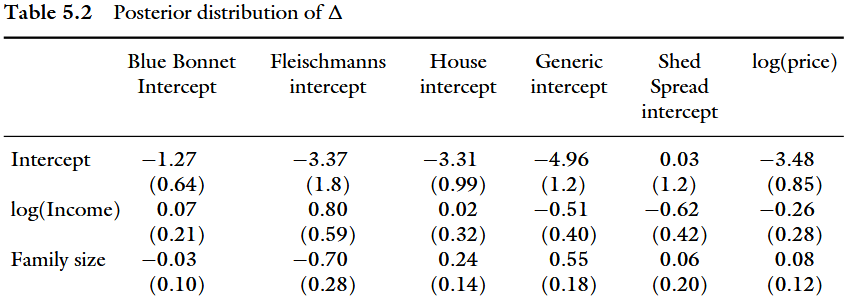

In [29]:
print("\n=== Correlations and standard deviations of betas ===")
display(df_cov_corr)


=== Correlations and standard deviations of betas ===


,Blue Bonnet,Fleischmanns,House,Generic,Shed Spread,log(price)
Blue Bonnet,1.54 (0.13),0.35 (0.14),0.42 (0.10),0.44 (0.10),0.27 (0.13),-0.10 (0.15)
Fleischmanns,,3.98 (0.63),0.25 (0.15),0.13 (0.17),0.08 (0.18),0.37 (0.18)
House,,,2.39 (0.19),0.84 (0.04),0.49 (0.10),-0.12 (0.15)
Generic,,,,2.96 (0.26),0.54 (0.11),-0.23 (0.15)
Shed Spread,,,,,3.01 (0.31),0.07 (0.16)
log(price),,,,,,1.43 (0.18)


Rossi 2006, p.141

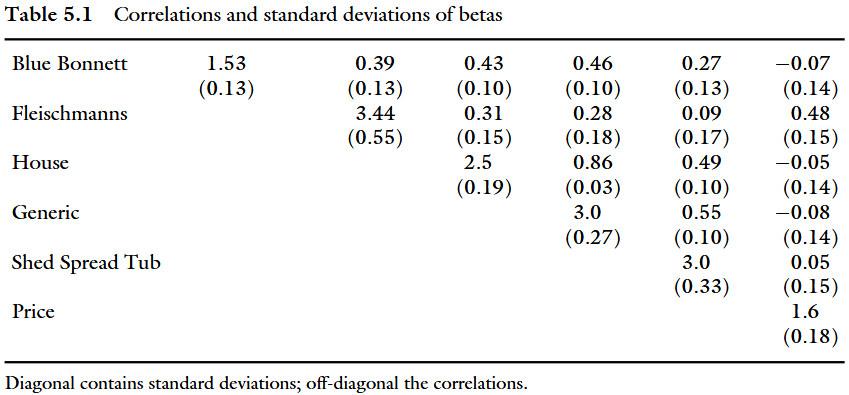

In [30]:
# TRACE PLOTS FOR MCMC DIAGNOSTICS

def plot_covariance_trace(samples):
    """Plots the MCMC trace for the latent variables in a lower-triangular matrix layout."""
    latent_samples = samples["sigma_inv_chol_latent"]
    
    # Handle both 3D (chains, draws, vars) and 2D (draws, vars) shapes
    if latent_samples.ndim == 3:
        n_chains, n_draws, n_latent = latent_samples.shape
    else:
        n_chains = 1
        n_draws, n_latent = latent_samples.shape
        latent_samples = latent_samples[None, :, :] # Add dummy chain dimension
        
    # Calculate the k_dim of the original matrix mathematically from n_latent
    # Since n_latent = k * (k + 1) / 2
    k_dim = int((-1 + np.sqrt(1 + 8 * n_latent)) // 2)
    
    fig, axes = plt.subplots(k_dim, k_dim, figsize=(15, 12), sharex=True, sharey=False)
    
    latent_idx = 0
    for i in range(k_dim):
        for j in range(k_dim):
            ax = axes[i, j]
            if i >= j and latent_idx < n_latent:
                for chain in range(n_chains):
                    ax.plot(latent_samples[chain, :, latent_idx], alpha=1, label=f"Chain {chain}")
                ax.set_title(f"Latent[{i},{j}]", fontsize=10)
                latent_idx += 1
            else:
                ax.axis('off')
                
            ax.grid(True, alpha=0.3)
            if i == k_dim - 1: ax.set_xlabel("Iteration")
            if j == 0: ax.set_ylabel("Value")

    # Add the legend at the bottom just like in your original code
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=n_chains, bbox_to_anchor=(0.5, 0.02))
    
    plt.suptitle(f"MCMC Trace: sigma_inv_chol_latent ({k_dim}x{k_dim} Matrix Structure)", fontsize=20)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

In [31]:
# POSTERIOR COVARIANCE DISTRIBUTIONS

def plot_final_covariance(samples, param_names):
    """Plots the posterior distribution of the covariance matrix elements."""
    k_dim = len(param_names)
    latent_samples = samples["sigma_inv_chol_latent"].reshape(-1, int(k_dim * (k_dim + 1) / 2))
    
    bijector = tfb.FillScaleTriL()
    def latent_to_cov(latent_vec):
        L = bijector.forward(latent_vec)
        precision_mat = L @ L.T
        return jnp.linalg.inv(precision_mat)

    v_latent_to_cov = jax.vmap(latent_to_cov)
    cov_draws = np.array(v_latent_to_cov(latent_samples)) 
    
    fig, axes = plt.subplots(k_dim, k_dim, figsize=(18, 16))
    
    diag_color = "#002347"  
    off_diag_color = "#4682B4"  

    for i in range(k_dim):
        for j in range(k_dim):
            ax = axes[i, j]
            if j > i:
                ax.axis('off') 
                continue
            
            data_vec = cov_draws[:, i, j]
            current_color = diag_color if i == j else off_diag_color
            
            post_mean = np.mean(data_vec)
            ci_low, ci_high = np.percentile(data_vec, [2.5, 97.5])
            
            sns.kdeplot(data_vec, ax=ax, fill=True, color=current_color, alpha=0.25, lw=2.5)
            ax.axvline(post_mean, color=current_color, linestyle="-", lw=1.5, alpha=0.8)
            ax.axvline(ci_low, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            ax.axvline(ci_high, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            
            ax.set_title(f"Mean: {post_mean:.2f}\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]", fontsize=10, pad=12)
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)
            
            if i == k_dim - 1: ax.set_xlabel(param_names[j], fontsize=12, fontweight='bold')
            if j == 0: ax.set_ylabel(param_names[i], fontsize=12, fontweight='bold')

    plt.suptitle("Posterior Distributions of the Covariance Matrix", fontsize=24, y=0.98)
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()

In [32]:
# UNIT-LEVEL HETEROGENEITY (BOXPLOTS)

def plot_unit_betas_boxplot(samples, param_names, param_indices_to_plot=[0, 5], max_units=100):
    """Plots boxplots of unit-level betas to visualize heterogeneity across households."""
    beta_samps = samples["beta_i"]
    
    # Flatten chains if necessary
    if beta_samps.ndim == 4:
        beta_samps = beta_samps.reshape(-1, beta_samps.shape[2], beta_samps.shape[3])
        
    n_units = beta_samps.shape[1]
    plot_units = min(n_units, max_units) # Limit to avoid completely unreadable x-axes
    
    for param_idx in param_indices_to_plot:
        param_name = param_names[param_idx]
        
        # Shape: (draws, units) -> restrict to max_units for visibility
        traces_2d = beta_samps[:, :plot_units, param_idx]
        
        plt.figure(figsize=(18, 5))
        sns.boxplot(data=traces_2d, color="white", showcaps=True,
                    boxprops={'facecolor': 'white', 'edgecolor': 'black'},
                    whiskerprops={'color': 'black'}, medianprops={'color': 'red', 'linewidth': 2},
                    showfliers=False, width=0.6)
        
        # Only label every 10th household to prevent overlapping text
        plt.xticks(range(0, plot_units, 10), range(0, plot_units, 10))
        plt.title(f"Posterior Ranges Across Households — {param_name}", fontsize=14)
        plt.xlabel("Household Index")
        plt.ylabel("Beta Value")
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

In [33]:
# POOLED POPULATION DISTRIBUTIONS

def plot_pooled_betas(samples, param_names):
    """Plots the overall pooled distribution of betas across all households."""
    beta_samps = samples["beta_i"]
    k_dim = len(param_names)
    
    plt.figure(figsize=(14, 7))
    for b in range(k_dim):
        # Flatten all draws and all units into a single array for this parameter
        arr = beta_samps[..., b].reshape(-1) 
        sns.kdeplot(arr, fill=True, alpha=0.25, linewidth=2, label=param_names[b])
        
    plt.title("Combined Population Distributions (All Households Pooled)", fontsize=16)
    plt.xlabel("Beta Value")
    plt.ylabel("Density")
    plt.grid(True, alpha=0.2)
    plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [34]:
def plot_covariance_dist(samples, param_names, true_matrix=None, empirical_matrix=None):
    """Plots the posterior distribution of the covariance matrix elements."""
    k_dim = len(param_names)
    latent_samples = samples["sigma_inv_chol_latent"].reshape(-1, int(k_dim * (k_dim + 1) / 2))
    
    bijector = tfb.FillScaleTriL()
    def latent_to_cov(latent_vec):
        L = bijector.forward(latent_vec)
        precision_mat = L @ L.T
        return jnp.linalg.inv(precision_mat)

    v_latent_to_cov = jax.vmap(latent_to_cov)
    cov_draws = np.array(v_latent_to_cov(latent_samples)) 
    
    fig, axes = plt.subplots(k_dim, k_dim, figsize=(18, 16))
    
    diag_color = "#002347"  
    off_diag_color = "#4682B4"  
    true_val_color = "#D62728"  
    emp_val_color = "#2CA02C"  

    for i in range(k_dim):
        for j in range(k_dim):
            ax = axes[i, j]
            if j > i:
                ax.axis('off') 
                continue
            
            data_vec = cov_draws[:, i, j]
            current_color = diag_color if i == j else off_diag_color
            
            post_mean = np.mean(data_vec)
            ci_low, ci_high = np.percentile(data_vec, [2.5, 97.5])
            
            sns.kdeplot(data_vec, ax=ax, fill=True, color=current_color, alpha=0.25, lw=2.5)
            
            ax.axvline(post_mean, color=current_color, linestyle="-", lw=1.5, alpha=0.8)
            ax.axvline(ci_low, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            ax.axvline(ci_high, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            
            title_parts = [f"Mean: {post_mean:.2f}"]
            if true_matrix is not None:
                ax.axvline(true_matrix[i, j], color=true_val_color, linestyle="--", lw=2)
                title_parts.append(f"True: {true_matrix[i, j]:.2f}")
            if empirical_matrix is not None:
                ax.axvline(empirical_matrix[i, j], color=emp_val_color, linestyle="-.", lw=2)
                title_parts.append(f"Emp: {empirical_matrix[i, j]:.2f}")

            ax.set_title(f"{' | '.join(title_parts)}\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]", fontsize=10, pad=12, fontweight='bold')
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)
            
            if i == k_dim - 1: ax.set_xlabel(param_names[j], fontsize=12, fontweight='bold')
            if j == 0: ax.set_ylabel(param_names[i], fontsize=12, fontweight='bold')

    # Rebuild Legend
    legend_elements = [
        Line2D([0], [0], color=off_diag_color, linestyle='-',  lw=2, label='Posterior Mean'),
        Line2D([0], [0], color=off_diag_color, linestyle=':',  lw=2, label='95% Credible Interval')
    ]
    if true_matrix is not None:
        legend_elements.append(Line2D([0], [0], color=true_val_color, linestyle='--', lw=2, label='True Parameter Value'))
    if empirical_matrix is not None:
        legend_elements.append(Line2D([0], [0], color=emp_val_color,  linestyle='-.', lw=2, label='Empirical Data Covariance'))
        
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.85, 0.85), fontsize=14, frameon=True, edgecolor='black')
    
    plt.suptitle("Posterior distributions of Covariance Matrix", fontsize=24, y=0.98, fontweight='light')
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()

In [35]:
def plot_unit_beta_overlays(samples, param_names, param_indices_to_plot=None):
    """Plots overlaid KDEs of unit-level betas for each specified parameter for all units."""
    beta_samps = samples["beta_i"]
    
    # Flatten chains if necessary: (chains, draws, units, params) -> (draws, units, params)
    if beta_samps.ndim == 4:
        beta_samps = beta_samps.reshape(-1, beta_samps.shape[2], beta_samps.shape[3])
        
    n_units = beta_samps.shape[1]
    k_dim = beta_samps.shape[2]
    
    if param_indices_to_plot is None:
        param_indices_to_plot = list(range(k_dim))
        
    for param_idx in param_indices_to_plot:
        param_name = param_names[param_idx]
        
        plt.figure(figsize=(12, 6))
        
        # Extract draws for this parameter, for all units
        # Shape: (draws, n_units)
        traces_2d = beta_samps[:, :, param_idx]
        
        # Plot every single unit's distribution
        for unit_idx in range(n_units):
            # Alpha set to 0.8 and no limit on the number of units plotted
            sns.kdeplot(traces_2d[:, unit_idx], color="blue", alpha=0.5, linewidth=1.2)
            
        plt.title(f"Overlay of Posterior Distributions for {param_name}", fontsize=14)
        plt.xlabel("Beta Value")
        plt.ylabel("Density")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

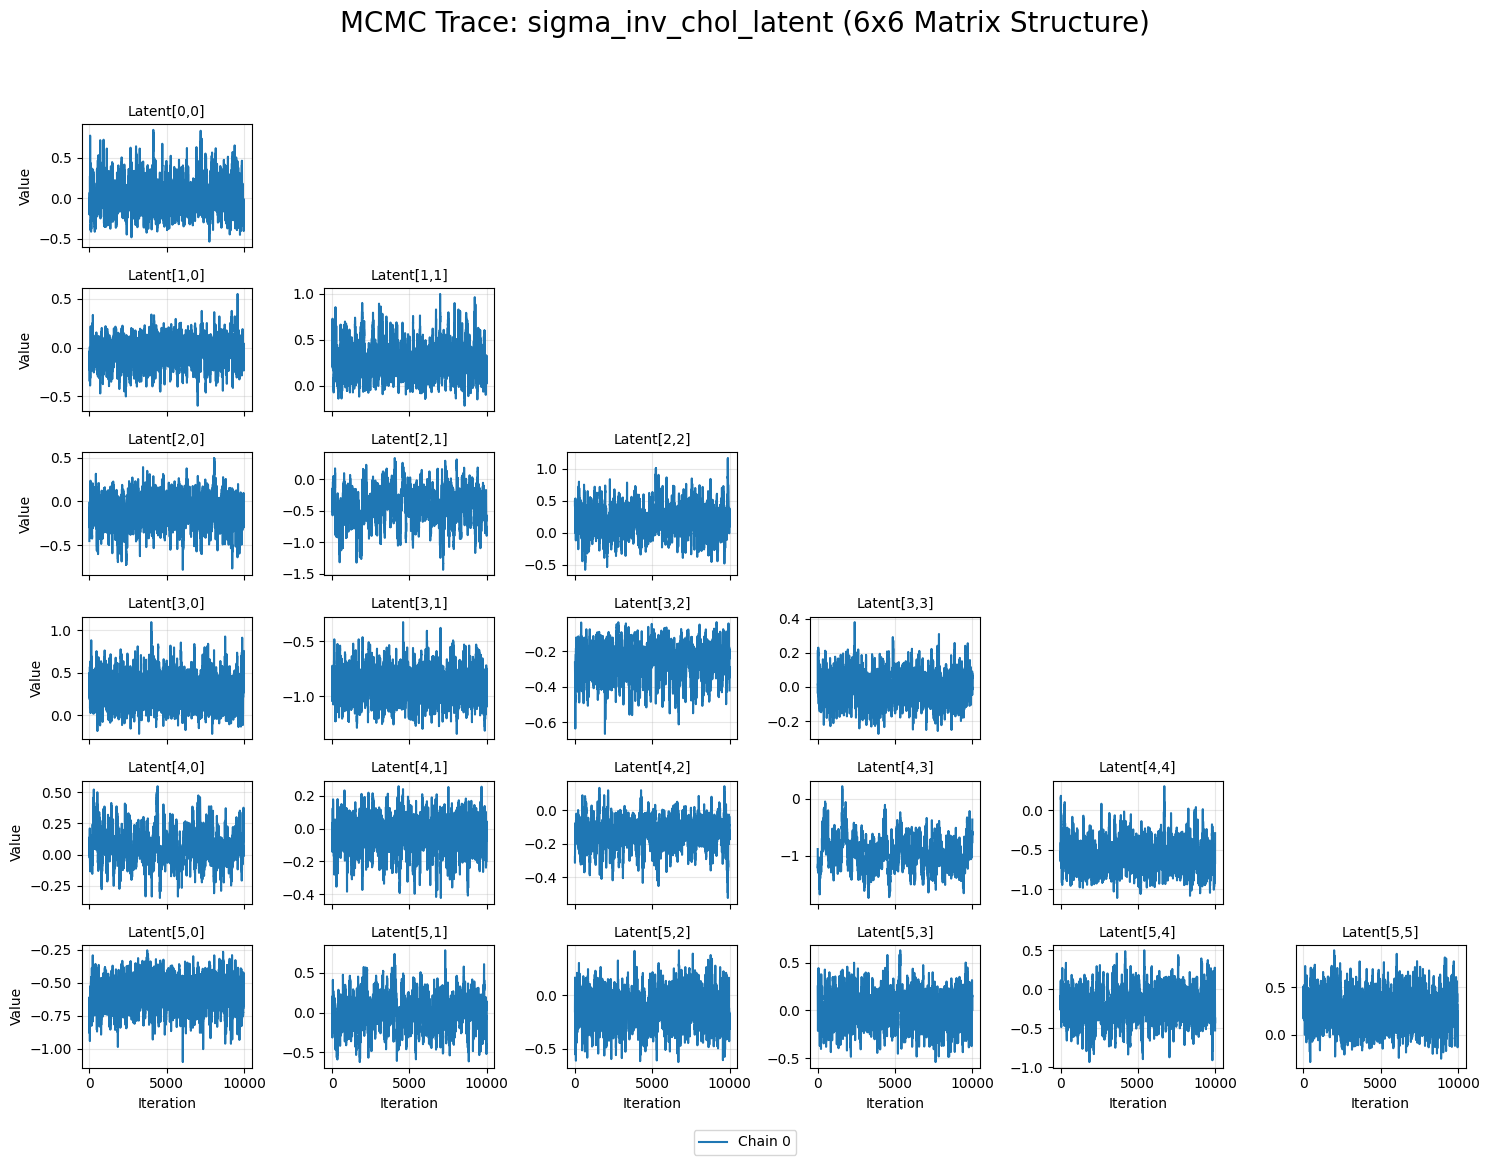

In [36]:
# Assuming you already have 'samples' and 'brand_names' defined:
plot_covariance_trace(samples)

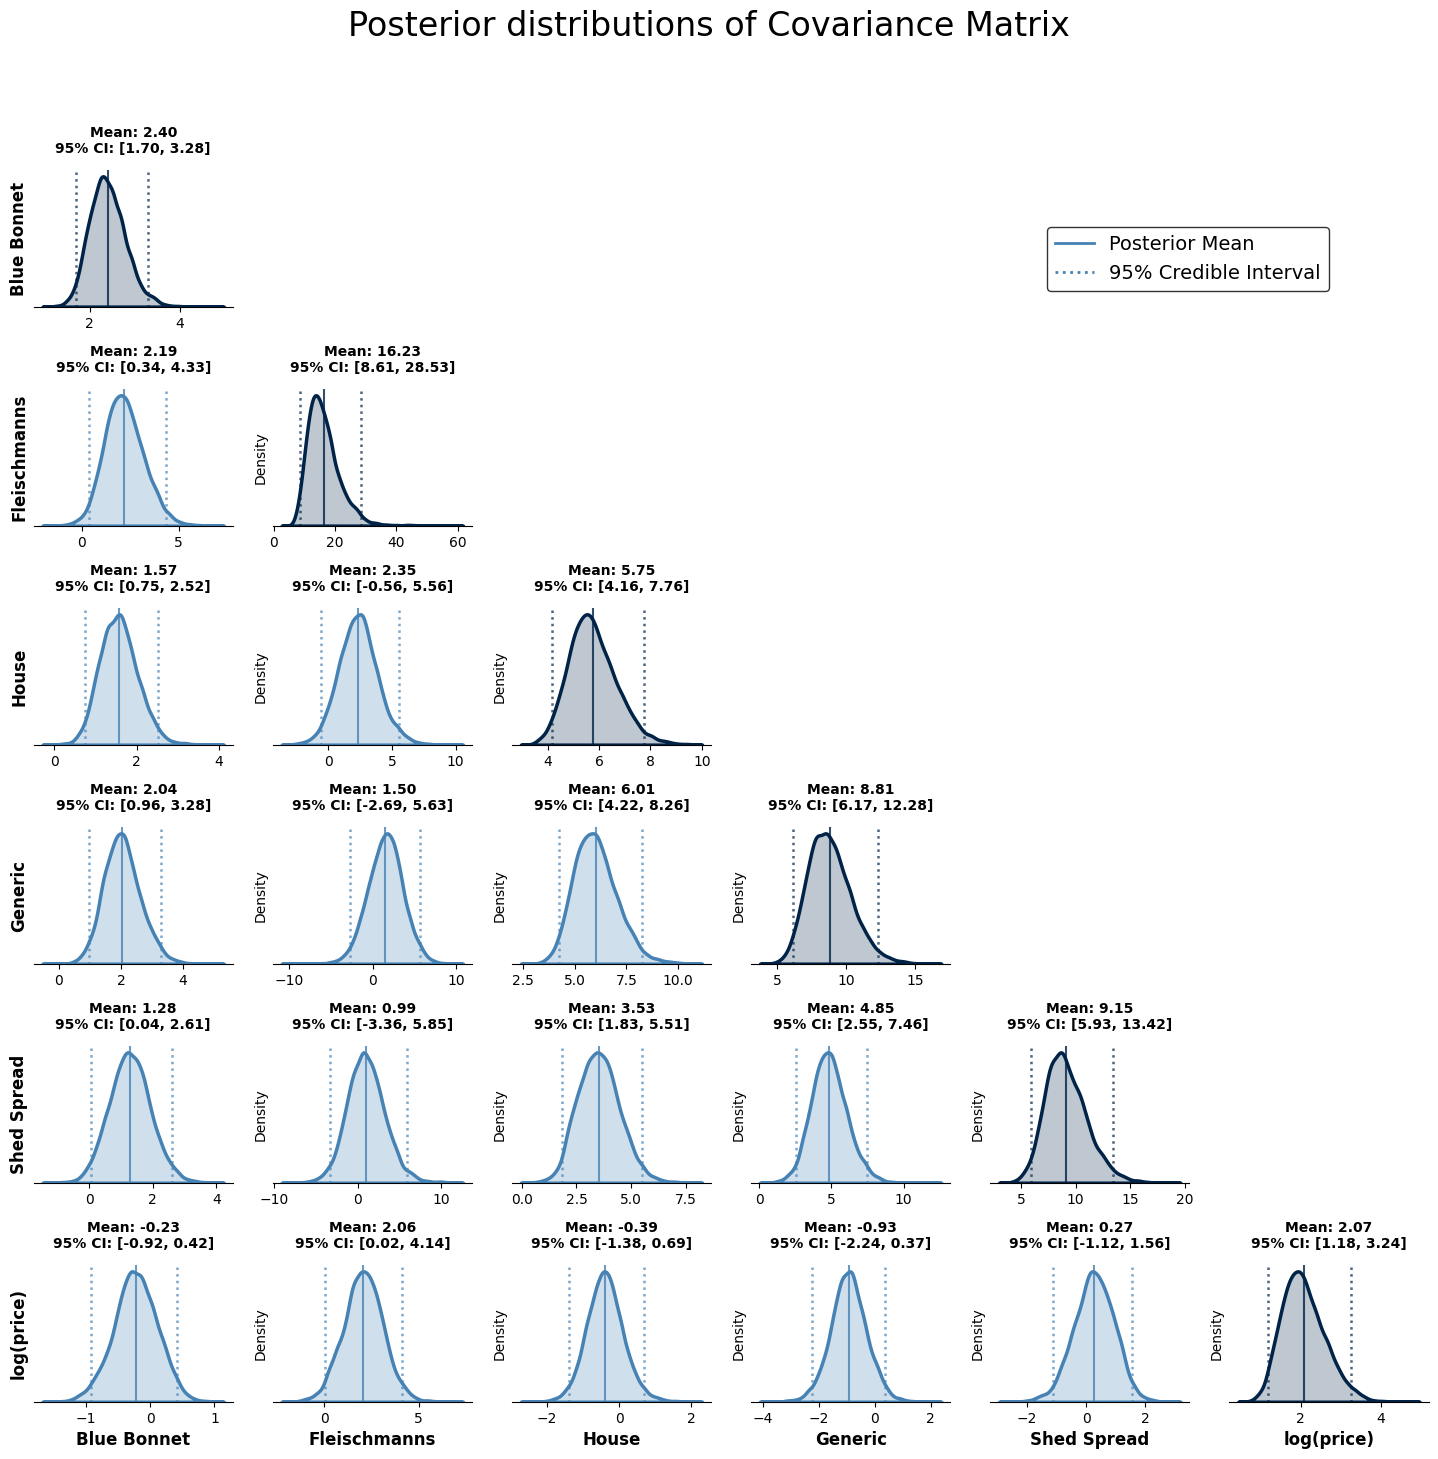

In [37]:
plot_covariance_dist(samples, brand_names)

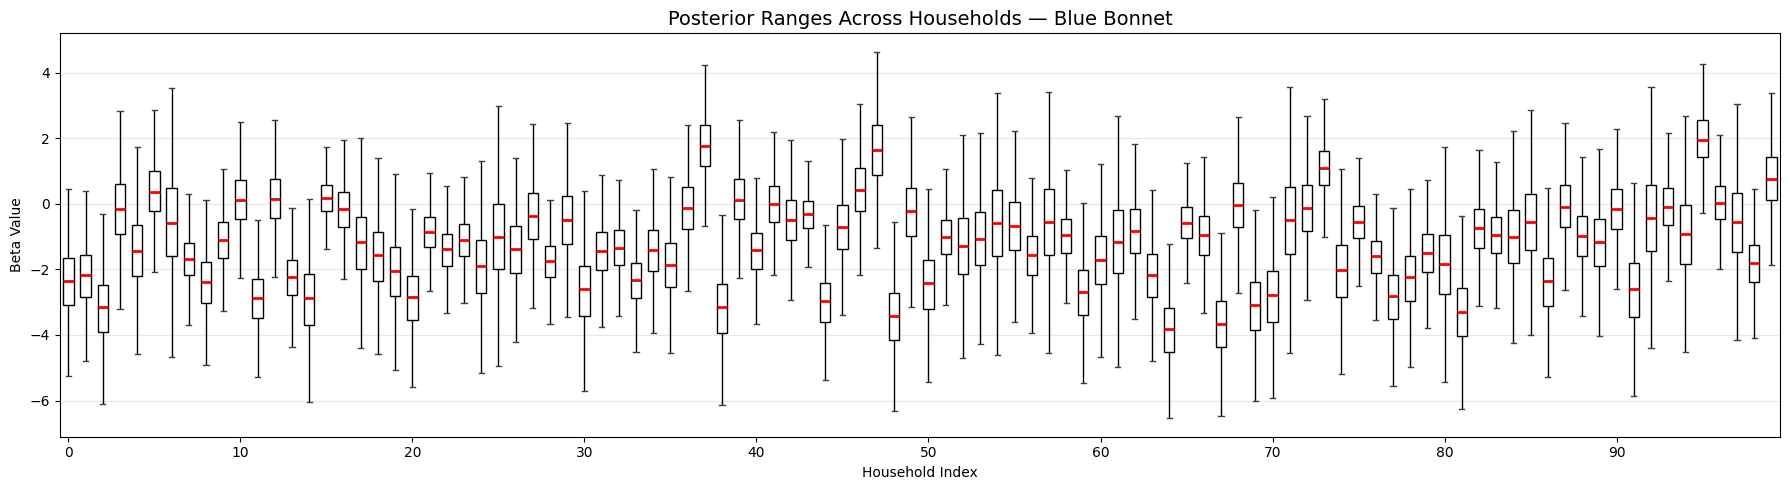

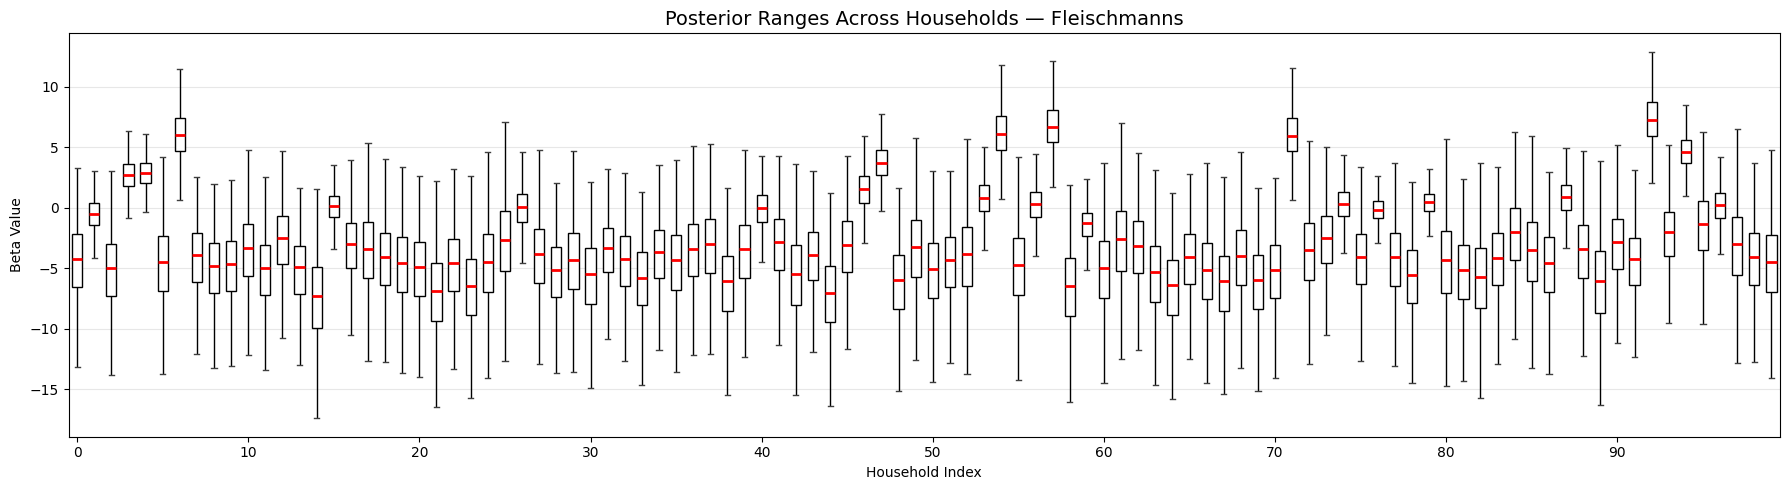

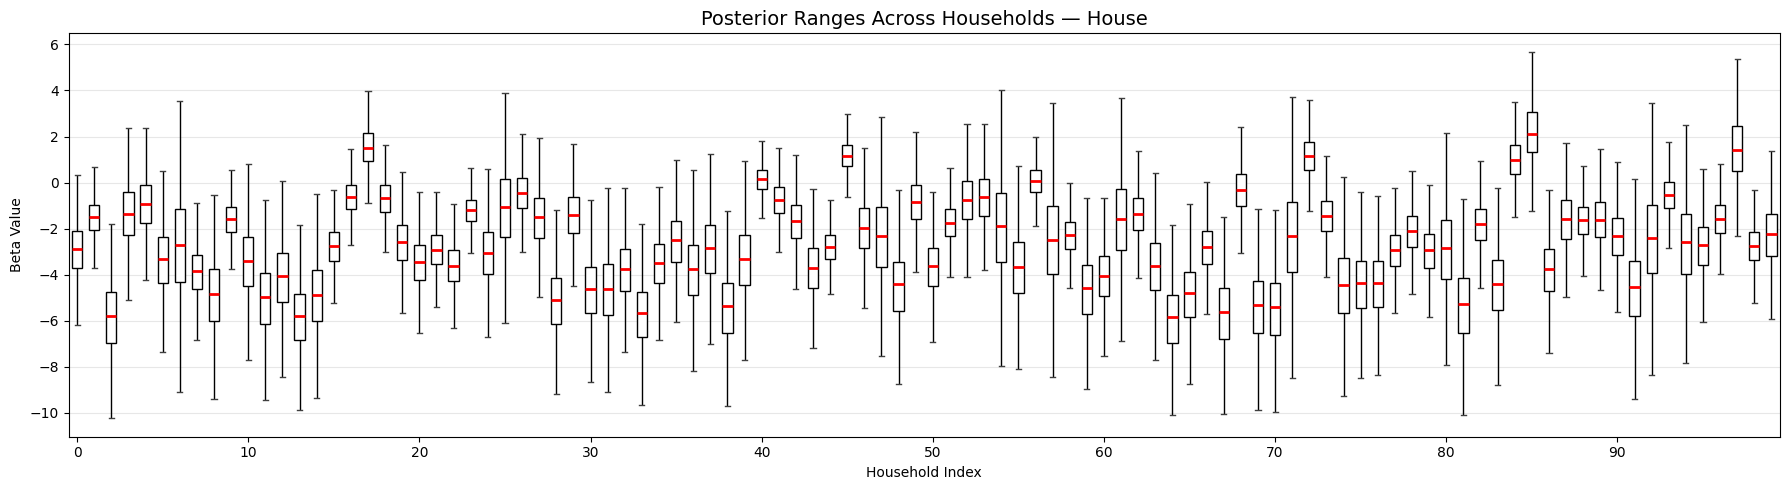

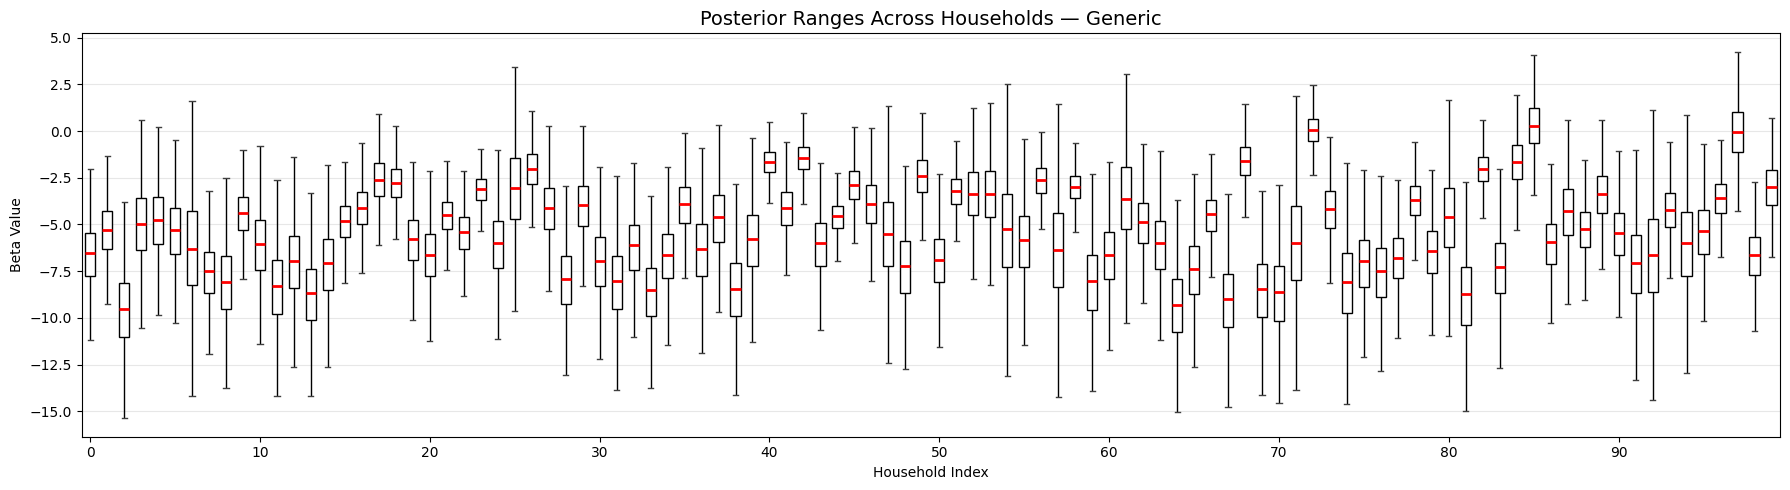

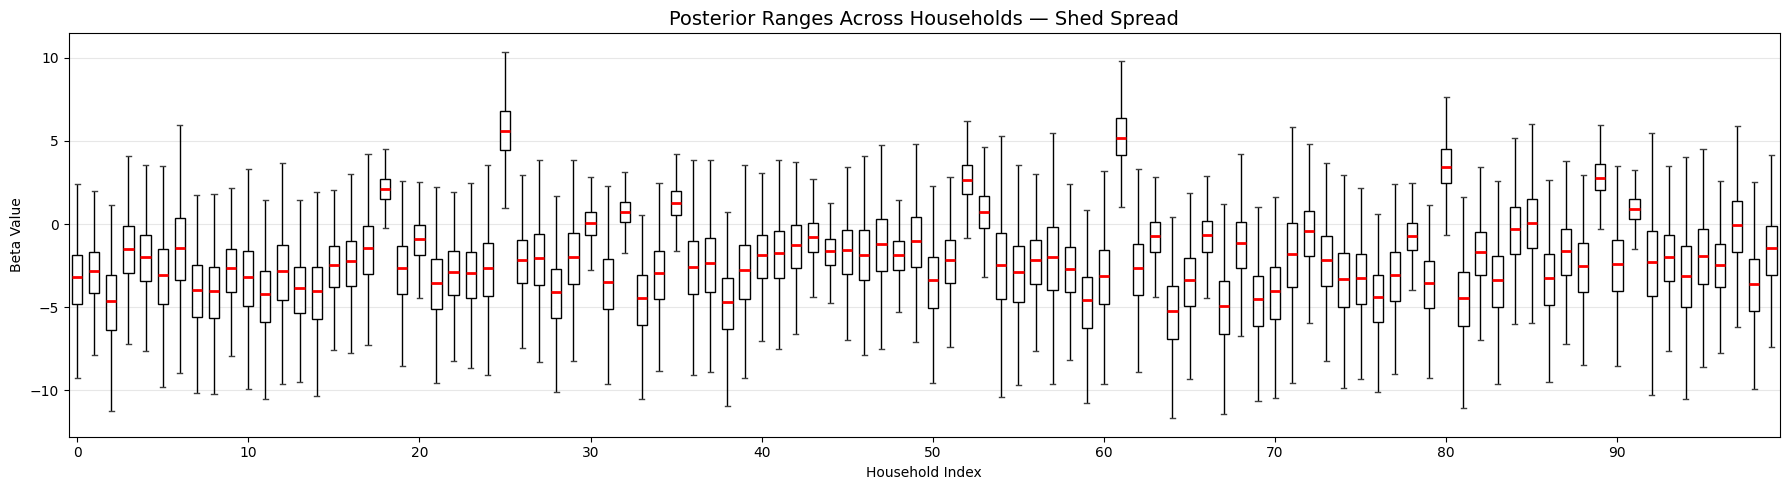

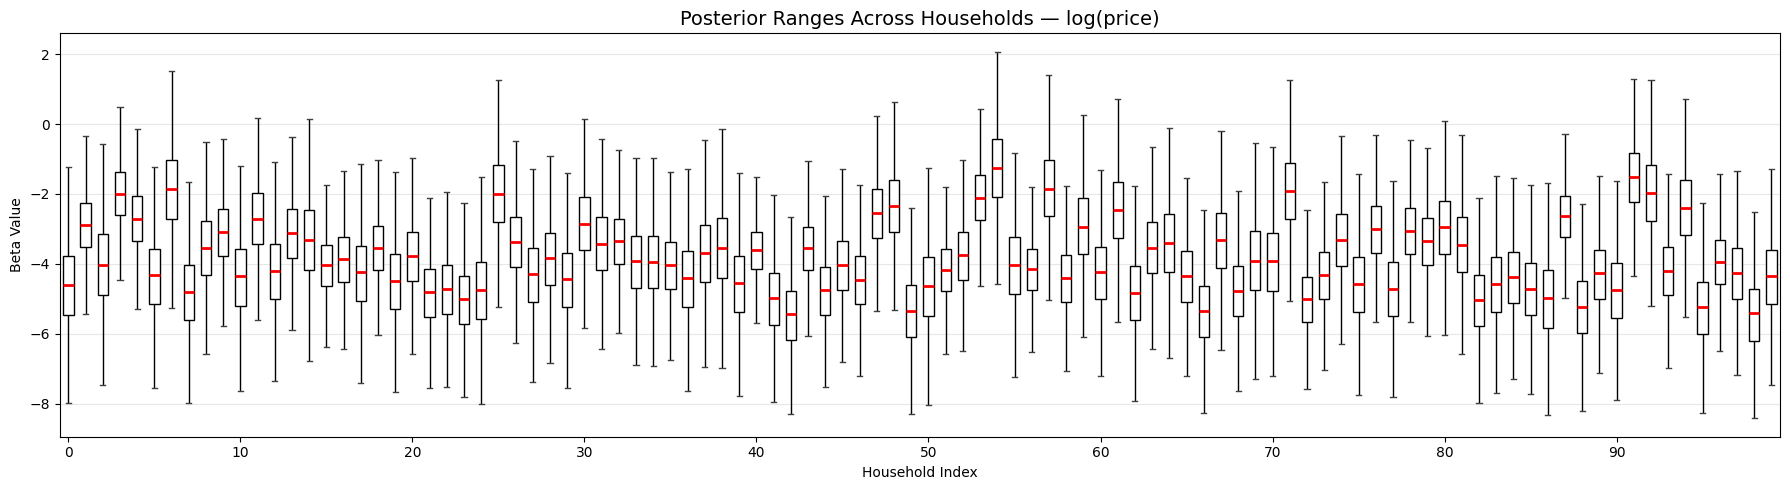

In [38]:
# Plot intercepts (index 0) and Price sensitivity (index 5)
plot_unit_betas_boxplot(samples, brand_names, param_indices_to_plot=[0,1,2,3,4,5])

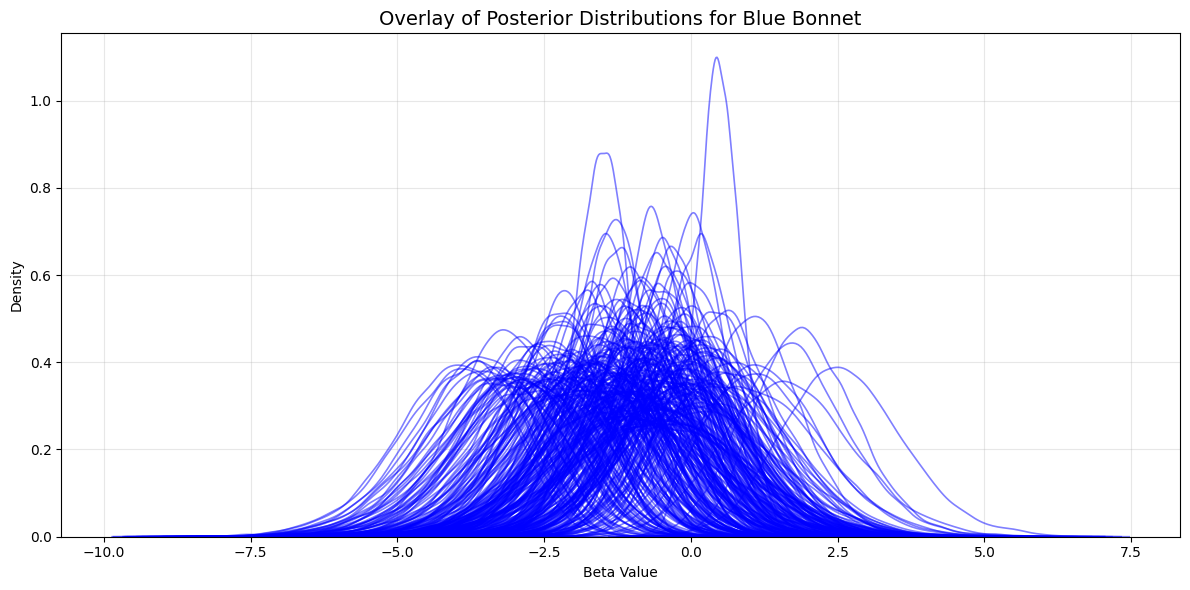

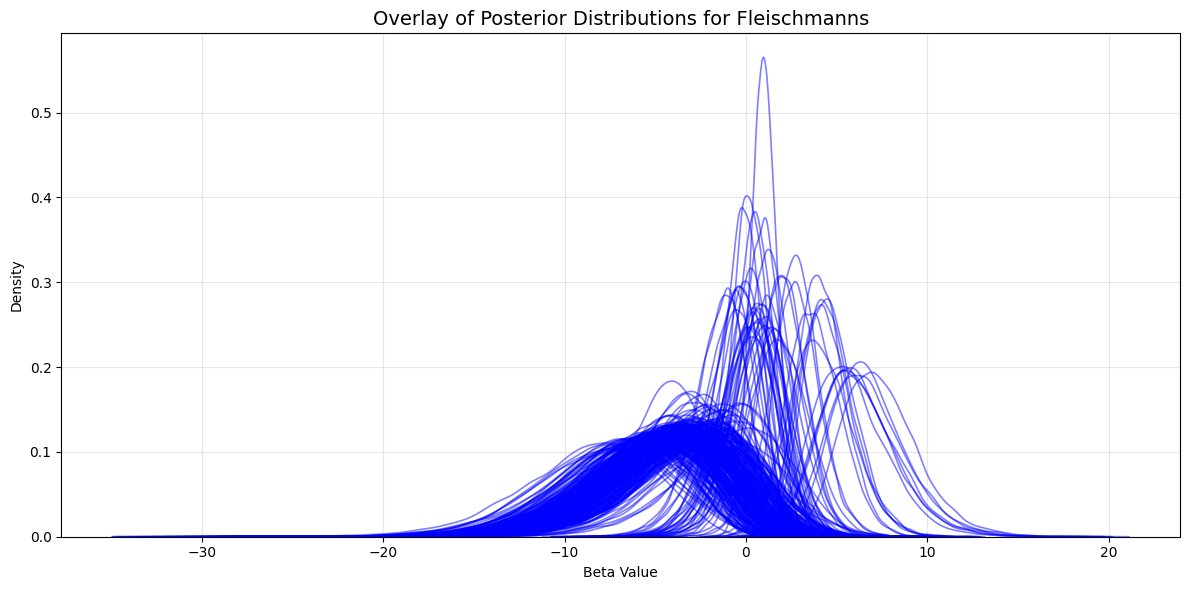

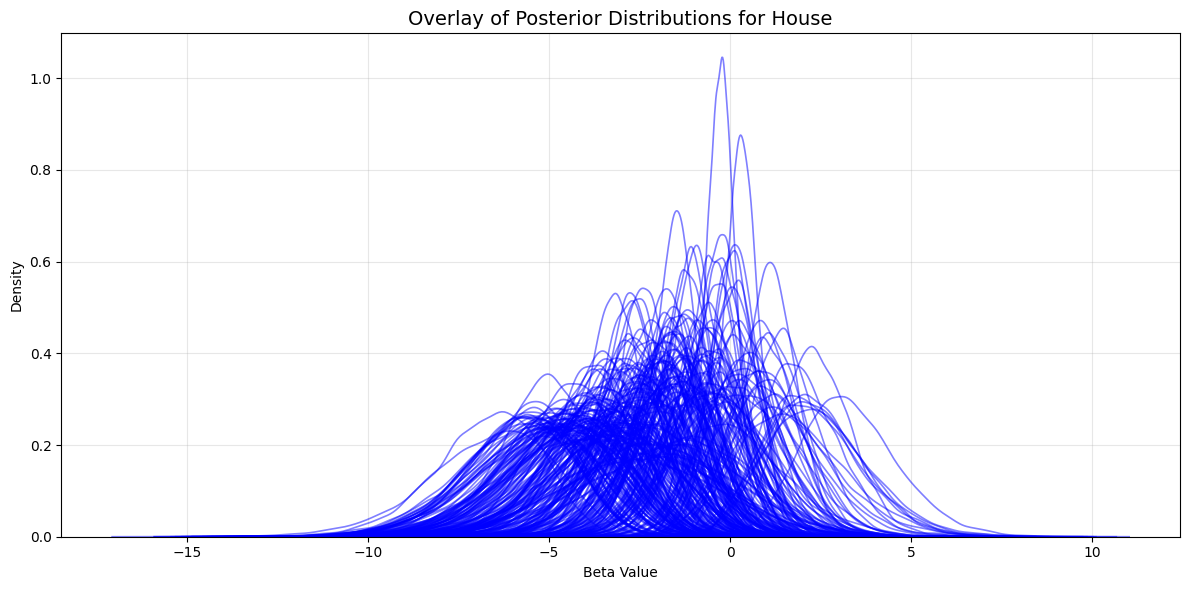

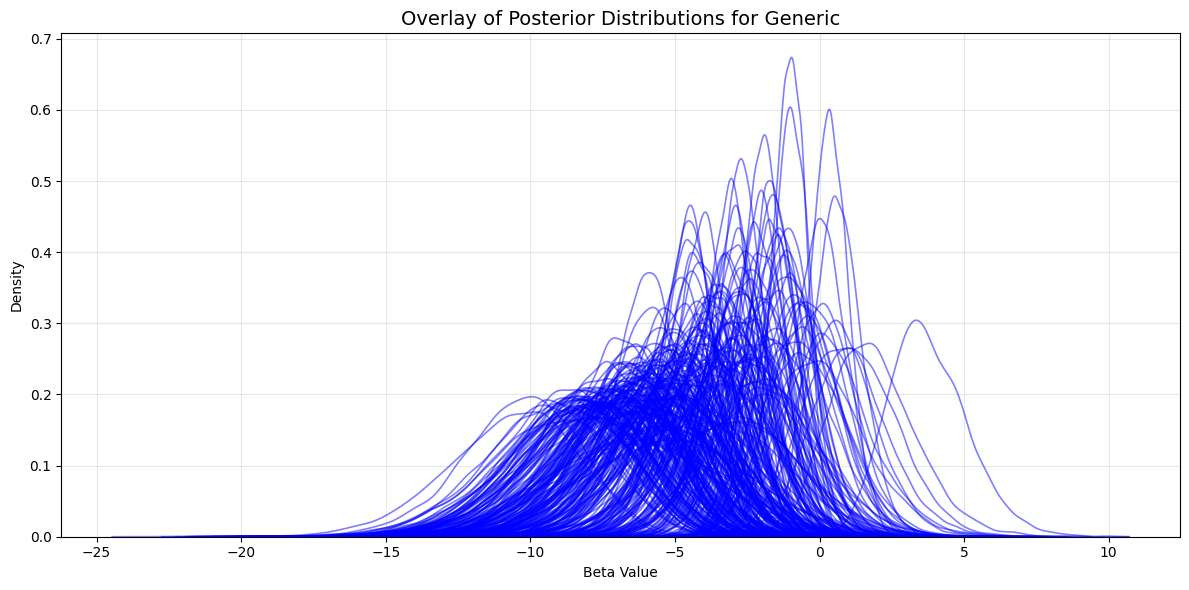

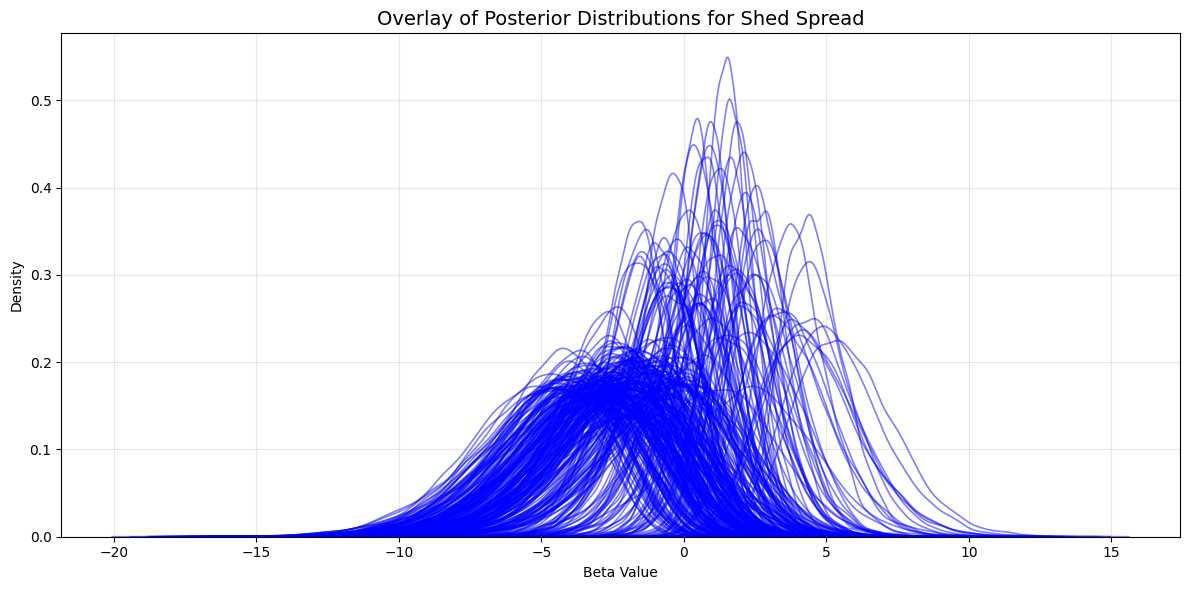

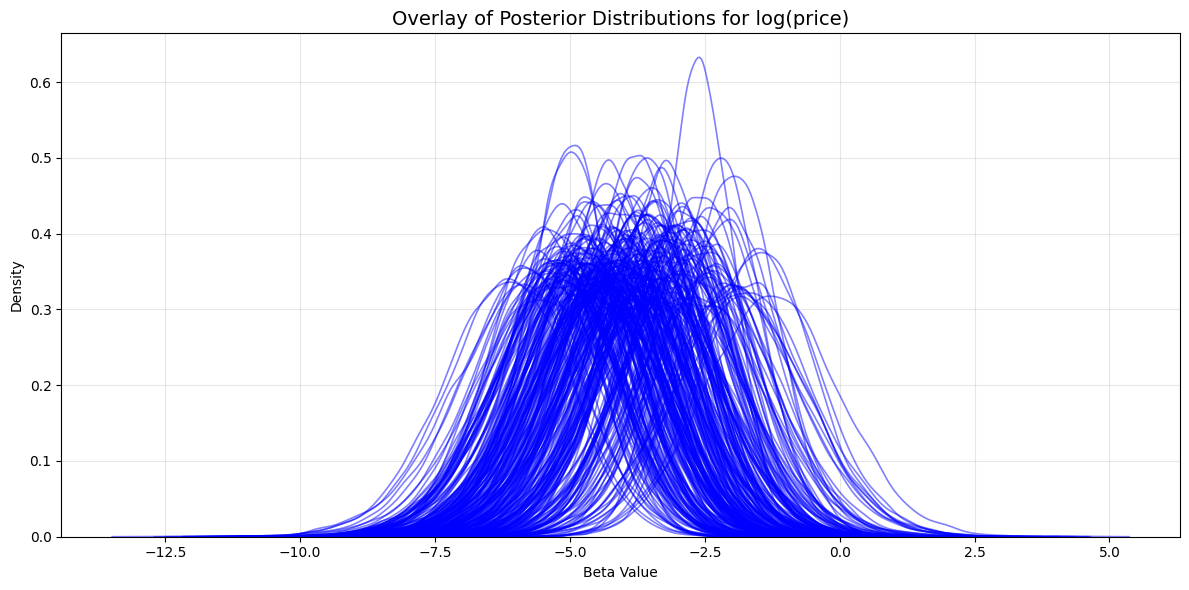

In [39]:
# Plot the overlays for all parameters (0 through 5)
plot_unit_beta_overlays(samples, brand_names, param_indices_to_plot=[0, 1, 2, 3, 4, 5])

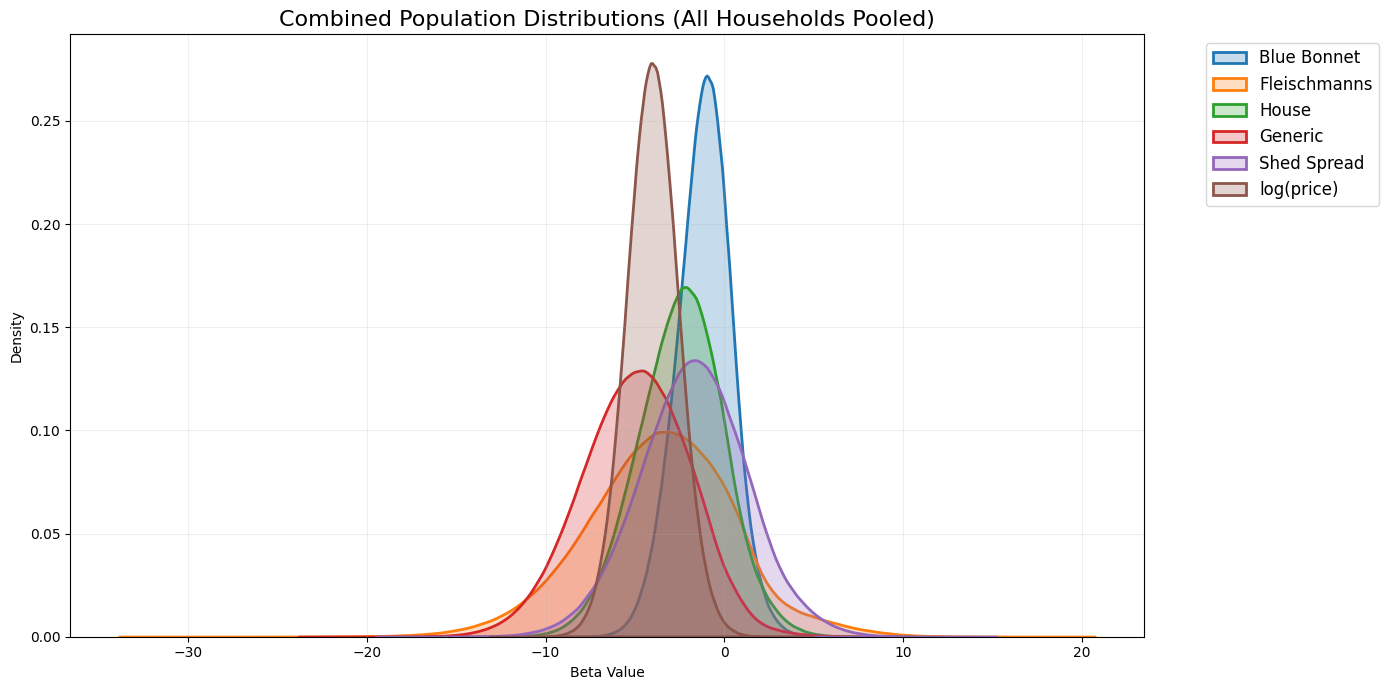

In [40]:
plot_pooled_betas(samples, brand_names)